In [22]:
import matplotlib.pyplot as plt
import numpy as np

KeysView(NpzFile './data/pwave_Tc.npz' with keys: best_free, mu, T, F_onsite, F_swave...)


d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


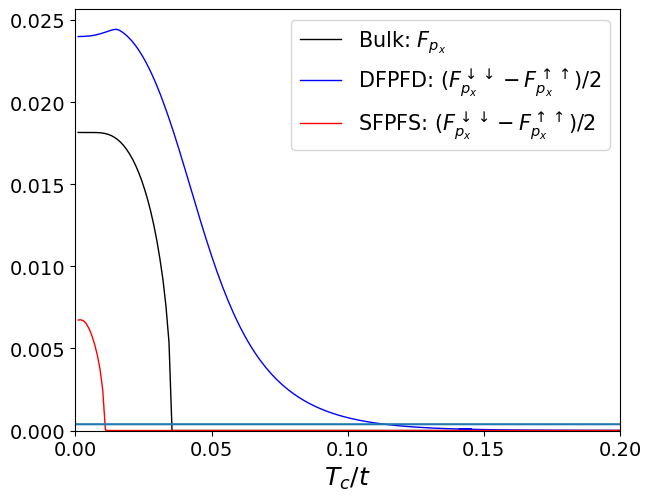

(0.0003826454279528498+5.440988297775545e-10j)


In [26]:
df_part = np.load('./data/SFPFS.npz')
df_sc = np.load('./data/SFPFS_sc.npz')
df_d = np.load('./data/DFPFD_v2.npz')
bulkP = np.load("./data/pwave_Tc.npz")

print(bulkP.keys())
temps_bulk = bulkP["T"]
F_px_bulk = bulkP["F_px"]
F_py_bulk = bulkP["F_py"]
temps = df_sc["temps"]
temps_d = df_d["temps"]
temps_s = df_part["temps"]
F0 = df_sc["F0"]
F_px_sc = (df_sc["Fuu_px"]-df_sc["Fdd_px"])/2
F_py_sc = (df_sc["Fuu_py"]+df_sc["Fdd_py"])/2
F_px_s = (df_part["Fuu_px"]-df_part["Fdd_px"])/2
F_py_s = (df_part["Fuu_py"]+df_part["Fdd_py"])/2
F_px_d = (df_d["Fuu_px"]-df_d["Fdd_px"])/2
F_py_d = (df_d["Fuu_py"]+df_d["Fdd_py"])/2

plt.figure(1)
plt.clf()

# plt.plot(temps, np.abs(F_px_sc), linewidth=1, label=r"SC S: $p_x$", color='')
plt.plot(temps_bulk, np.abs(F_px_bulk), "-", linewidth=1, label=r"Bulk: $F_{p_x}$", color='black')
plt.plot(temps_d, np.abs(F_px_d), "-", linewidth=1, 
         label=r"DFPFD: $(F^{\downarrow\downarrow}_{p_x}-F^{\uparrow\uparrow}_{p_x})/2$", color='blue')
plt.plot(temps, np.abs(F_px_sc), "-", linewidth=1, 
         label=r"SFPFS: $(F^{\downarrow\downarrow}_{p_x}-F^{\uparrow\uparrow}_{p_x})/2$", color='red')
plt.plot(F0)
# plt.plot(temps, np.abs(F_py_sc), "-", label=r"Both: $p_y$", color='red')
# plt.plot(temps_d, np.abs(F_py_d), "--", label=r"DFPFD: $p_y$", color='blue')
# plt.plot(temps_s, np.abs(F_py_s), "--", label=r"SFPFS: $p_y$", color='red')

# plt.xlabel("T", fontsize=15)
plt.legend(loc="best", fontsize=15)
plt.yticks(fontsize=14)
plt.xticks([0, 0.05, 0.1, 0.15, 0.20],fontsize=14)
plt.tight_layout()
plt.xlim(0,0.2)
plt.ylim(0, None)

plt.xlabel('$T_c/t$', fontsize=18)

# plt.savefig('../../figures/DFPFD_Tc_curve.svg', bbox_inches='tight')
plt.show()
print(F0[0])


In [ ]:
import json
import glob
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = "data/pwave_Tc"
OUT_NPZ  = "data/pwave_Tc.npz"

SKIP_FIELDS = {"best_free", "free"}

def to_complex(val) -> complex:
    """Convert a JSON value to complex: handles {real, imag} dicts or plain numbers."""
    if isinstance(val, dict):
        return complex(val.get("real", 0.0), val.get("imag", 0.0))
    return complex(val)


def best_index(data: dict) -> str:
    """Return the key whose 'best_free' value is lowest."""
    return min(data["best_free"], key=lambda k: data["best_free"][k])


def extract_file(path: str) -> dict:
    with open(path) as f:
        data = json.load(f)

    idx = best_index(data)

    row = {"best_free": data["best_free"][idx],
           "source_file": Path(path).name}

    for field, values in data.items():
        if field in SKIP_FIELDS or field == "source_file":
            continue
        if isinstance(values, dict) and idx in values:
            row[field] = to_complex(values[idx])
        # else: field not present for this index — skip

    return row


files = sorted(glob.glob(f"{DATA_DIR}/*.json"))
if not files:
    raise FileNotFoundError(f"No JSON files found in '{DATA_DIR}'")

print(f"Found {len(files)} files – extracting…")

rows = [extract_file(p) for p in files]
df = pd.DataFrame(rows)
df.sort_values("T", inplace=True)
df.reset_index(drop=True, inplace=True)

np_arrays = {}
for col in df.columns:
    if col == "source_file":
        continue
    arr = df[col].to_numpy()
    if np.iscomplexobj(arr) and np.all(np.imag(arr) == 0):
        arr = np.real(arr).astype(np.float64)
    np_arrays[col] = arr

np.savez(OUT_NPZ, **np_arrays)

for key, arr in np_arrays.items():
    print(f"  {key:20s}  shape={arr.shape}  dtype={arr.dtype}")

Found 180 files – extracting…
  best_free             shape=(180,)  dtype=float64
  mu                    shape=(180,)  dtype=float64
  T                     shape=(180,)  dtype=float64
  F_onsite              shape=(180,)  dtype=float64
  F_swave               shape=(180,)  dtype=float64
  F_dwave               shape=(180,)  dtype=float64
  F_px                  shape=(180,)  dtype=complex128
  F_py                  shape=(180,)  dtype=complex128
  Fuu_px                shape=(180,)  dtype=float64
  Fuu_py                shape=(180,)  dtype=float64
  Fdd_px                shape=(180,)  dtype=float64
  Fdd_py                shape=(180,)  dtype=float64
